# Notebook B — Expression génique et régulation

**Notebook B — Stage de lycée · Laboratoire de microbiologie quantitative**

Ce notebook explore comment la cellule contrôle *quand* et *combien* une protéine
est fabriquée. On part d'un modèle élémentaire (un gène qui clignote au hasard)
pour arriver à l'analyse de vos propres données de fluorescence en plaque reader.

---

### Comment utiliser ce notebook
- Exécuter chaque cellule dans l'ordre : **Shift + Entrée**
- Lire les questions `>` et y réfléchir avant de passer à la suite
- Modifier les paramètres et observer ce qui change

> **Environnement recommandé** : [Google Colab](https://colab.research.google.com) — aucune installation.
> En local : `pip install numpy matplotlib pandas`
>
> **Durée estimée** : §B1–§B2 ≈ 2 demi-journées · §B3 ≈ 2 demi-journées · Notebook C facultatif

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size']  = 12
print("Bibliotheques chargees.")

Bibliotheques chargees.


---
## Section B1 — Le gène comme interrupteur stochastique

Dans la cellule, un **promoteur** est une région d'ADN qui contrôle si le gène en
aval sera transcrit. Mais ce contrôle est **probabiliste** : à chaque instant, la
machinerie cellulaire peut déclencher une transcription ou non, indépendamment du passé.

Modèle simple : le promoteur est *actif* avec probabilité $p_{\text{on}}$ à chaque
pas de temps.

> **Question** : si $p_{\text{on}} = 0.3$, quelle fraction du temps le gène est-il actif ?
> Si le niveau maximal d'expression (gène toujours actif, $p_{\text{on}} = 1$)
> correspond à une fluorescence de 1000 unités, quelle fluorescence moyenne
> attend-on dans une population de cellules identiques ?

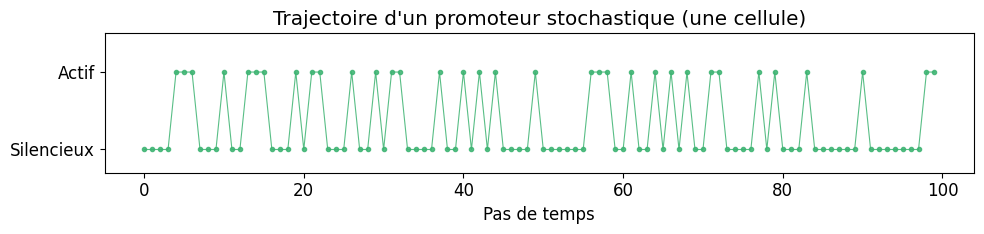

Fraction du temps actif : 0.34  (p_on = 0.3)
Ces deux valeurs doivent etre proches !


In [2]:
# ── Paramètres ─────────────────────────────────────────────────────────────────
p_on = 0.3    # probabilite que le promoteur soit actif a chaque pas de temps
n_t  = 100    # nombre de pas de temps

# ── Simuler l'état du promoteur au cours du temps ──────────────────────────────
np.random.seed(42)
etat = []
for t in range(n_t):
    if np.random.random() < p_on:
        etat.append(1)       # gene actif -> GFP produite
    else:
        etat.append(0)       # gene silencieux

# ── Tracé ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 2.5))
plt.plot(etat, 'o-', color='mediumseagreen', ms=3, lw=0.8, alpha=0.85)
plt.ylim(-0.3, 1.5)
plt.xlabel("Pas de temps")
plt.yticks([0, 1], ["Silencieux", "Actif"])
plt.title("Trajectoire d'un promoteur stochastique (une cellule)")
plt.tight_layout()
plt.show()

print(f"Fraction du temps actif : {sum(etat)/len(etat):.2f}  (p_on = {p_on})")
print("Ces deux valeurs doivent etre proches !")

### Variabilité entre cellules

Même si $p_{\text{on}}$ est identique dans toutes les cellules,
chacune joue sa propre séquence de pile-ou-face indépendante.

En mesurant la fluorescence de beaucoup de cellules au même instant,
on observe une **distribution** — pas une valeur unique.

> **Question** : attendez-vous une distribution large ou étroite ? Pourquoi ?

> **Note technique** : la forme de l'histogramme dépend un peu du nombre de classes
> choisi. On fixe ici des classes régulières de largeur 0.05 pour éviter cet effet.

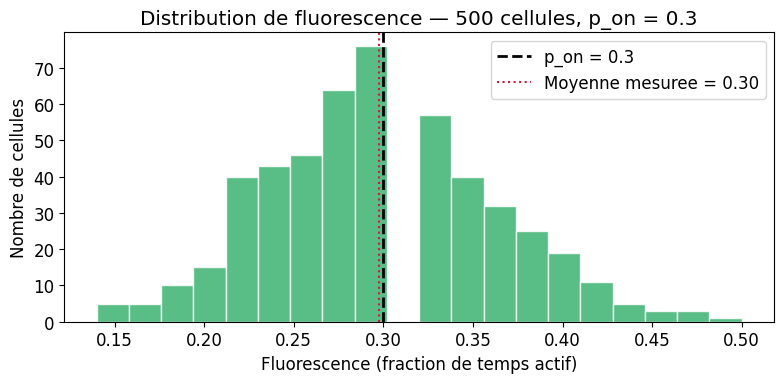

Moyenne    : 0.297  (attendu : 0.3)
Ecart-type : 0.064

-> Meme avec un parametre identique pour toutes les cellules,
   la fluorescence varie. Ce bruit est irreductible :
   il vient du hasard des evenements moleculaires.


In [9]:
# ── Paramètres ─────────────────────────────────────────────────────────────────
N_cells = 500
n_t_fl  = 50     # nombre de pas pour estimer la fluorescence de chaque cellule

# ── Simuler la fluorescence de N cellules ──────────────────────────────────────
fluorescence = []
for i in range(N_cells):
    # Pour chaque cellule : fraction du temps ou son promoteur etait actif
    etats_cellule = np.random.random(n_t_fl) < p_on
    fluorescence.append(np.mean(etats_cellule))
fluorescence = np.array(fluorescence)

# ── Histogramme ────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.hist(fluorescence, bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
plt.axvline(p_on,                color='black',  lw=2,   linestyle='--',
            label=f'p_on = {p_on}')
plt.axvline(fluorescence.mean(), color='crimson', lw=1.5, linestyle=':',
            label=f'Moyenne mesuree = {fluorescence.mean():.2f}')
plt.xlabel("Fluorescence (fraction de temps actif)")
plt.ylabel("Nombre de cellules")
plt.title(f"Distribution de fluorescence — {N_cells} cellules, p_on = {p_on}")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne    : {fluorescence.mean():.3f}  (attendu : {p_on})")
print(f"Ecart-type : {fluorescence.std():.3f}")
print()
print("-> Meme avec un parametre identique pour toutes les cellules,")
print("   la fluorescence varie. Ce bruit est irreductible :")
print("   il vient du hasard des evenements moleculaires.")

### Vers la courbe d'induction

Dans le labo, on contrôle $p_{\text{on}}$ en ajoutant un inducteur chimique (l'IPTG).
L'IPTG se lie au répresseur LacI et l'empêche de bloquer le promoteur.

Si la concentration est $[I]$ et si le répresseur a une affinité $K$ pour l'IPTG,
la probabilité que le répresseur soit débloqué vaut :

$$p([I]) = \frac{[I]}{K + [I]}$$

Traçons ce que ça donne pour plusieurs valeurs de $[I]$.

  [IPTG] =    0 µM  ->  p = 0.000
  [IPTG] =    1 µM  ->  p = 0.032
  [IPTG] =    3 µM  ->  p = 0.091
  [IPTG] =   10 µM  ->  p = 0.250
  [IPTG] =   30 µM  ->  p = 0.500
  [IPTG] =  100 µM  ->  p = 0.769
  [IPTG] =  300 µM  ->  p = 0.909


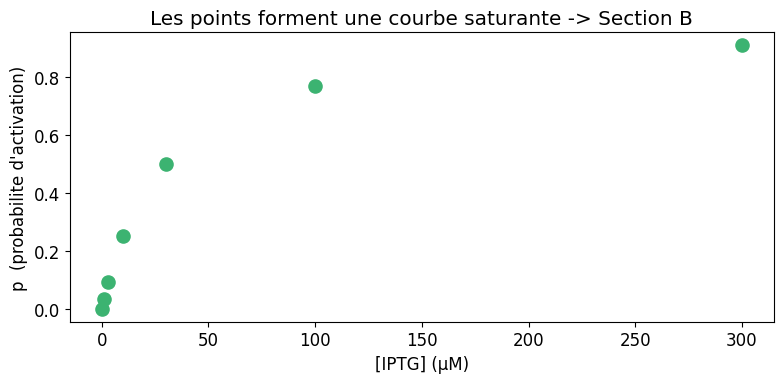

In [10]:
# ── Paramètre ───────────────────────────────────────────────────────────────────
K = 30    # affinite du represseur pour l'IPTG (µM)
          # = concentration a laquelle p = 0.5

# ── Calculer p pour chaque concentration ───────────────────────────────────────
concentrations_IPTG = [0, 1, 3, 10, 30, 100, 300]

p_vals = []
for I in concentrations_IPTG:
    p = I / (K + I)
    p_vals.append(p)
    print(f"  [IPTG] = {I:4d} µM  ->  p = {p:.3f}")

# ── Tracé ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(concentrations_IPTG, p_vals, color='mediumseagreen', s=90, zorder=3)
plt.xlabel("[IPTG] (µM)")
plt.ylabel("p  (probabilite d'activation)")
plt.title("Les points forment une courbe saturante -> Section B")
plt.tight_layout()
plt.show()

---
## Section B2 — Courbes dose-réponse : un verrou ou deux ?

### Architecture de l'opéron *lac* et les deux promoteurs étudiés

#### L'opéron *lac*

L'opéron *lac* est un groupe de gènes (*lacZ*, *lacY*, *lacA*) qui permettent à
*E. coli* d'utiliser le lactose comme source de carbone. Ils sont tous sous le contrôle
d'un seul **promoteur** — la région d'ADN qui décide si ces gènes sont transcrits ou non.

Le promoteur *lac* est régulé par une protéine répresseur, LacI, qui peut se fixer sur des
sites spécifiques de l'ADN appelés **opérateurs** pour bloquer la transcription.
En présence de lactose (ou de molécules analogues comme l'IPTG), ces molécules se lient à LacI et l'empêchent de bloquer :
c'est ainsi que les gènes *lac* sont exprimés pour utiliser ce nutriment. Au labo, on utilise aussi des molecules qui ressemblent au lactose mais que E. coli ne peut pas manger pour controler l'induction du promoteur *lac*: l'IPTG et le TMG. Comme elles ne sont pas degradés par les bacteries, l'interpretation des experiences d'induction est moins compliquée avec ces molécules qu'avec le lactose.

**Schémas : régulation de l'opéron *lac***

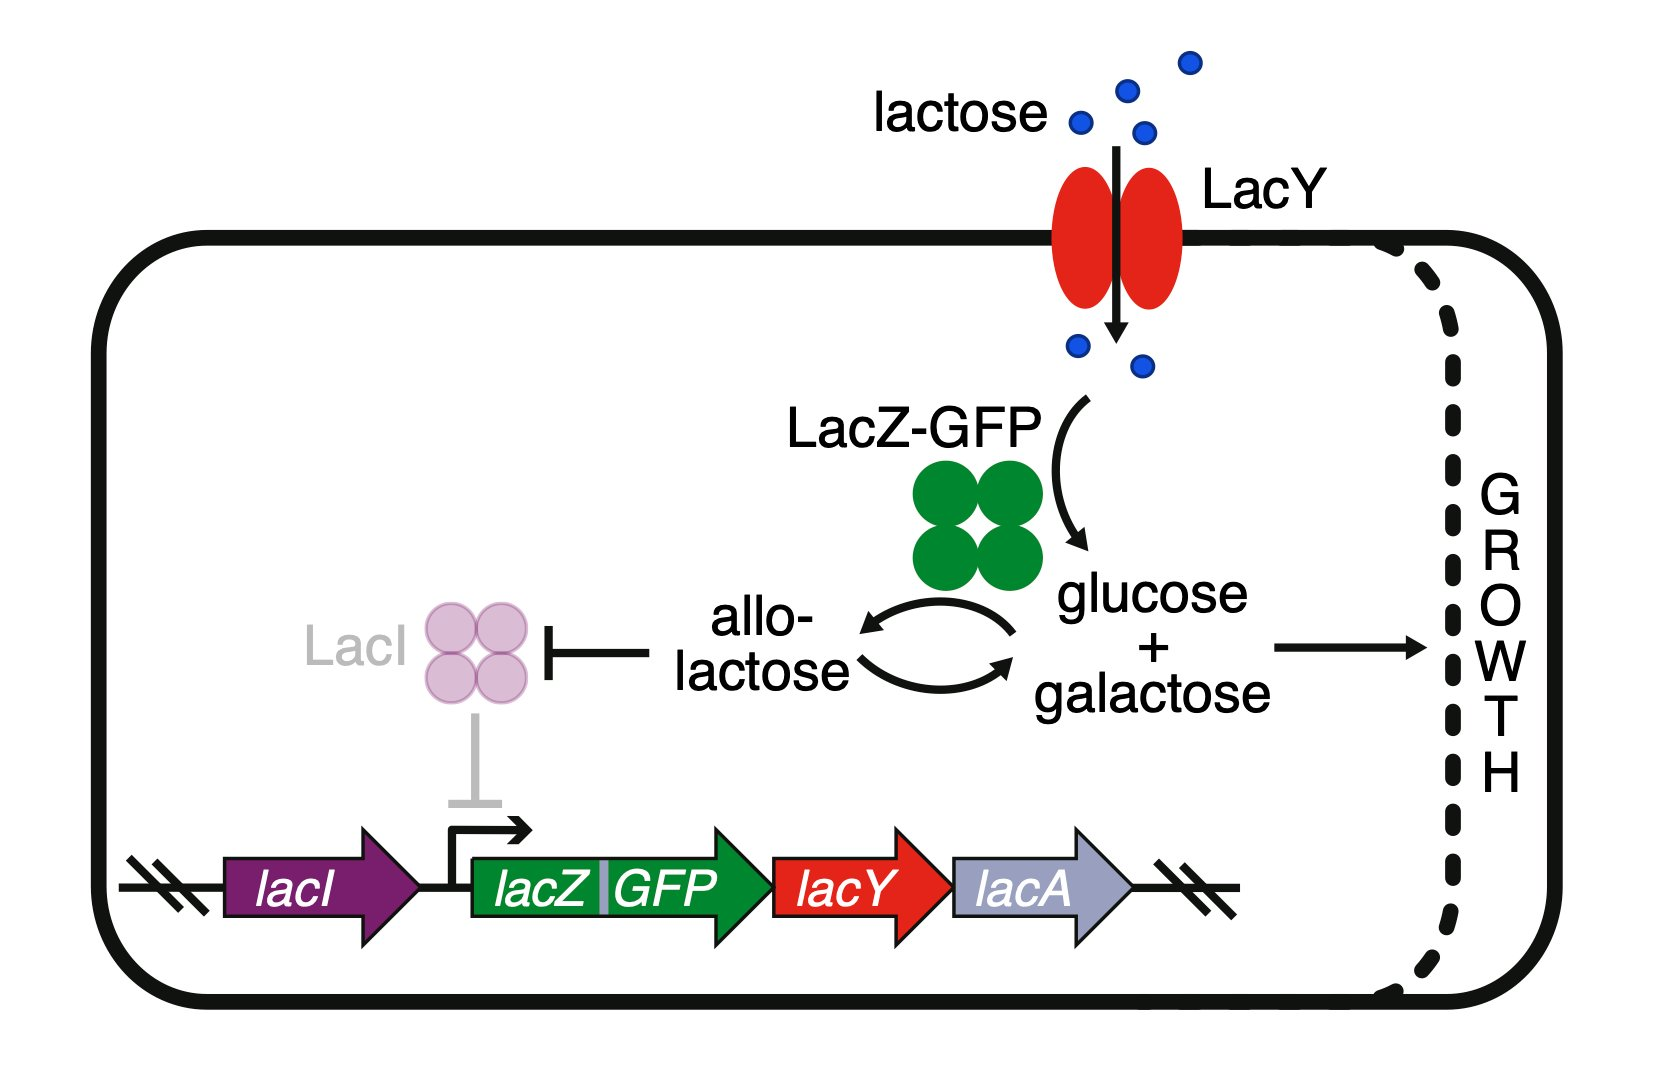

*Figure 1 — Induction naturelle par le lactose : LacY importe le lactose, LacZ le convertit en allolactose qui inactive LacI.*

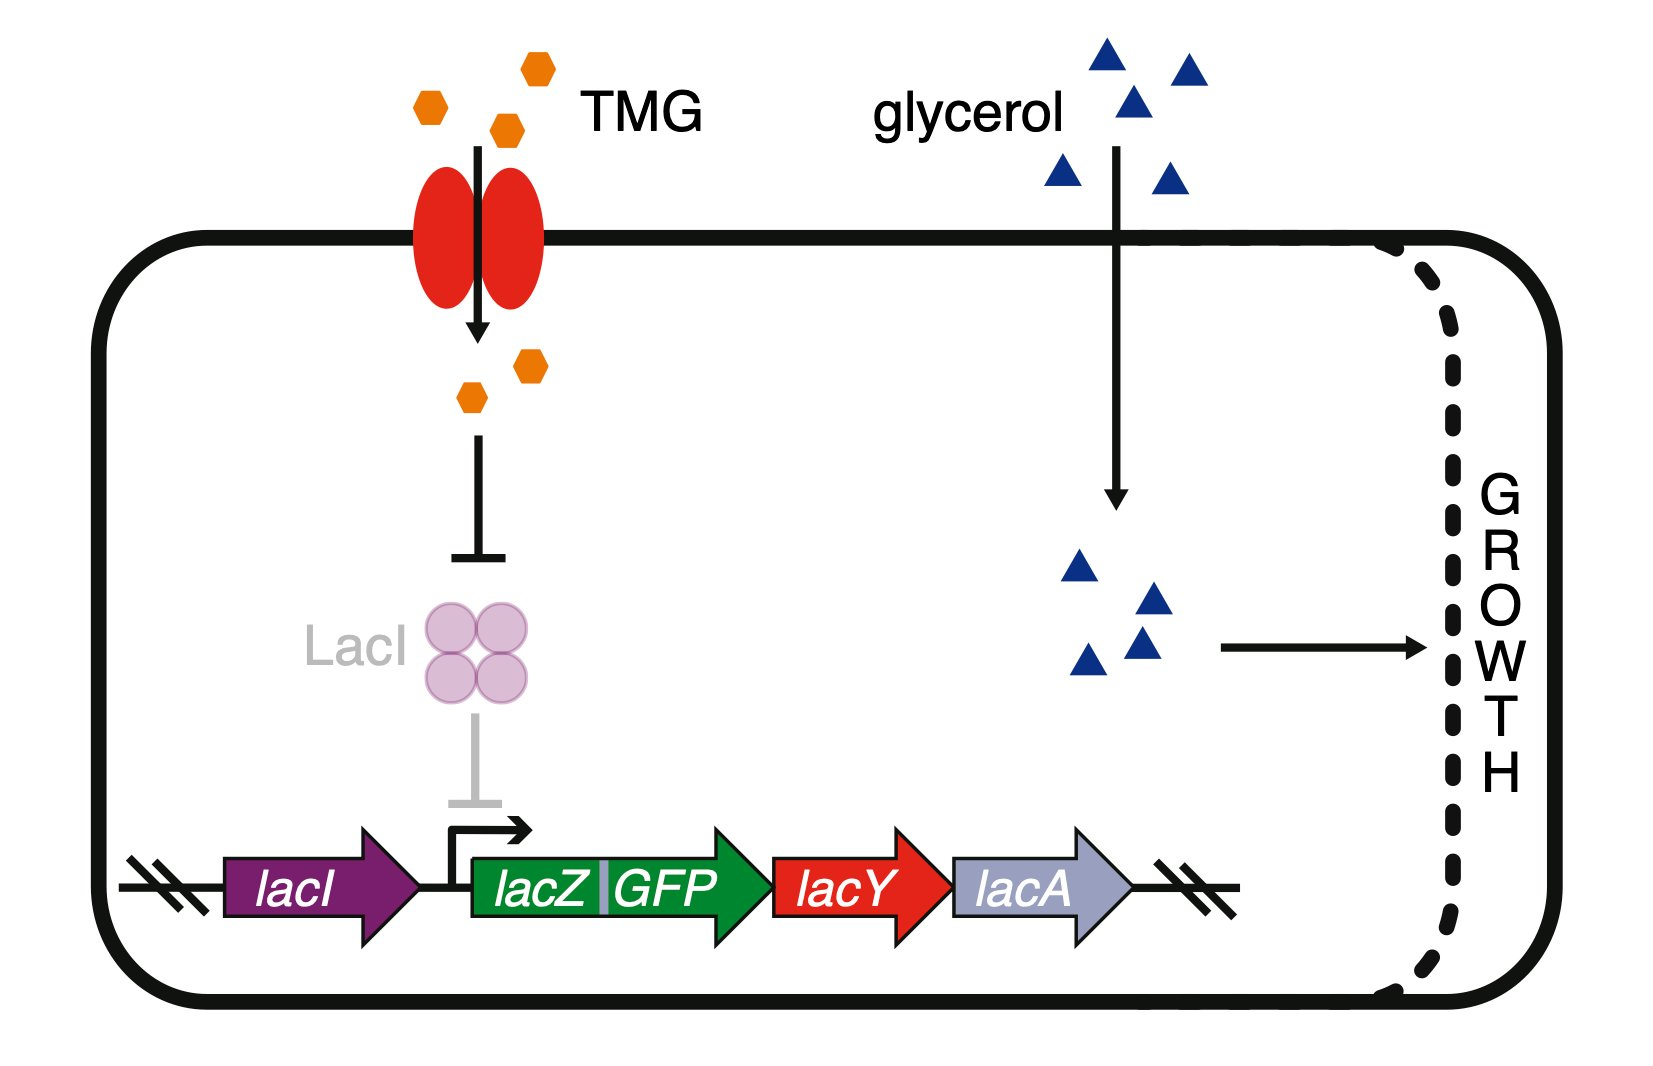

*Figure 2 — Induction expérimentale par le TMG (ou IPTG) : le TMG entre via LacY et inactive LacI, sans être dégradé. Au labo, on utilise de l'arabinose comme source de carbone (à la place du glycérol).*

On va comparer l'induction du promoteur *lac* natif, et d'un promoteur modifié qui ne contient qu'un seul operateur, lacO1 – ce promoteur s'appelle *lacUV5*.

**Comparaison des trois constructs :**

**1. Opéron *lac* natif (dans le chromosome)**

chr — *lacI* — [lacO3] — [σ70↓ / CRP↑] — [lacO1] — *lacZ* — *lacY* — *lacA* — chr

**2. Rapporteur Plac dans pUA66**

pUA66 — *lacI*∆ (40 bp) — [lacO3] — [σ70↓ / CRP↑] — [lacO1] — *lacZ*∆ (255 bp) — **GFP** — pUA66

**3. Rapporteur PlacUV5 dans pUA66**

pUA66 — *lacI*∆ (40 bp) — [lacO3✗] — [σ70↑ UV5] — [lacO1] — *lacZ*∆ (255 bp) — **GFP** — pUA66

> **Différences clés** : dans pUA66-lacUV5, O3 est inactivé (pas de boucle ADN → n ≈ 1) et les mutations UV5 rendent le promoteur fort et indépendant de CRP.


#### Les trois opérateurs de Plac natif

Le promoteur *lac* natif possède **trois opérateurs** :

| Opérateur | Position | Rôle |
|---|---|---|
| **O1** | région centrale (−10) | opérateur principal, le plus fort |
| **O3** | −82 bp en amont de O1 | opérateur secondaire |
| **O2** | +412 bp en aval de O1 | opérateur secondaire |

LacI peut se fixer **simultanément sur O1 et O3** en formant une **boucle d'ADN**
(les 82 pb entre les deux sites se replient en boucle). Cette coopérativité renforce
le blocage : pour activer le promoteur, il faut débloquer les deux sites à la fois.
→ Réponse sigmoïde, $n \approx 2$.

NB: On ne s'interesse pas à lacO2 dans ce stage.

#### Le promoteur PlacUV5 a un seul opérateur

Le second rapporteur est basé sur le promoteur *lacUV5*, dérivé du promoteur *lac* natif. Ce rapporteur:

- **Inclut O1** (seul opérateur fonctionnel) — pas de boucle ADN possible
- **Exclut O3** — la sequence a été changée pour le desactiver
- Porte les **deux mutations UV5** dans la région −10 (TATGTT → TATAAT),
  qui rendent le promoteur plus actif (et indépendant de la source de carbone, car la liaison de l'activateur CRP est aussi inactivée)

Sans boucle ADN, chaque molécule de LacI agit indépendamment via O1 seul.
→ Réponse hyperbolique, $n \approx 1$.

> **En résumé** : c'est l'**architecture du promoteur** — et non la séquence de LacI
> ou de l'inducteur — qui détermine la forme de la courbe dose-réponse.

### Modelisation mathematique de la reponse du promoteur *lac*

La formule $p = [I]/(K+[I])$ est une **courbe hyperbolique** (loi de Hill, ordre $n=1$).
Elle décrit un promoteur avec **un seul opérateur** : une seule molécule de répresseur
suffit pour bloquer le gène.

Le promoteur **Plac natif** possède trois opérateurs (O1, O2, O3).
Le répresseur peut former une **boucle d'ADN** en se fixant simultanément sur O1 et O3.
Pour activer le gène, il faut débloquer *les deux sites à la fois*.

Si les deux débloquages sont indépendants, la règle de **multiplication des probabilités**
(programme de seconde) donne :

$$p_{\text{total}} = p_1 \times p_2 = \frac{[I]}{K+[I]} \times \frac{[I]}{K+[I]} = \frac{[I]^2}{(K+[I])^2}$$

En notation compacte (loi de Hill d'ordre $n$) :

$$p = \frac{[I]^n}{K^n + [I]^n}$$

> **Note sur la simplification** : le produit exact donne $(K+[I])^2 = K^2 + 2K[I] + [I]^2$
> au dénominateur. La loi de Hill écrit plutôt $K^2 + [I]^2$ — le terme $2K[I]$ est omis.
> Les deux formules ont des $K_{1/2}$ légèrement différents, mais des formes très proches ;
> nous utilisons la loi de Hill $[I]^n/(K^n+[I]^n)$ dont le demi-maximum vaut exactement $K$,
> ce qui facilite la lecture graphique. C'est une approximation acceptable pour notre objectif.

- $n=1$ pour **P_lacUV5** (fragment $-60$ à $+25$, opérateur O1 seul, pas de boucle)
- $n=2$ pour **P_lac natif** (O1 + boucle ADN avec O3)

> **Note** : en réalité O1 et O3 ont des affinités différentes — simplification pédagogique.

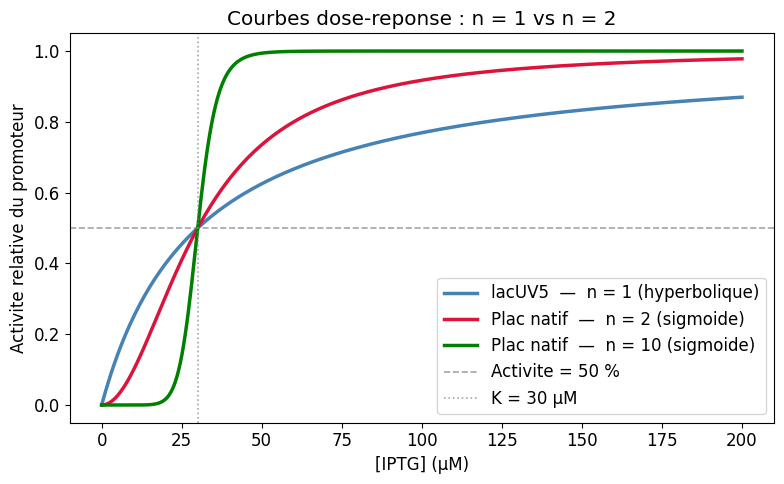

Pour les deux courbes : K_half = K = 30 µM.
Mais la courbe n=2 a une transition plus abrupte.
-> C'est la signature de la cooperativite.


In [14]:
# ── Axe x dense pour courbes lisses ────────────────────────────────────────────
I_vals = np.linspace(0, 200, 400)
K = 30    # demi-saturation (µM)

# ── Hill n=1 : lacUV5, opérateur O1 seul ───────────────────────────────────────
f_n1 = I_vals / (K + I_vals)

# ── Hill n=2 : Plac natif, O1 + boucle ADN ─────────────────────────────────────
# Derivation : p_total = p1 x p2 = [I/(K+I)]^2  ~  I^2 / (K^2 + I^2)
f_n2 = I_vals**2 / (K**2 + I_vals**2)

# ── Hill n=10 : pour comparaison ─────────────────────────────────────
f_n10 = I_vals**10 / (K**10 + I_vals**10)


# ── Tracé ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(I_vals, f_n1, color='steelblue', lw=2.5, label='lacUV5  —  n = 1 (hyperbolique)')
plt.plot(I_vals, f_n2, color='crimson',   lw=2.5, label='Plac natif  —  n = 2 (sigmoide)')
plt.plot(I_vals, f_n10, color='green',  lw=2.5,
         label='Cooperativite forte  —  n = 10 (exemple theorique)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, lw=1.2, label='Activite = 50 %')
plt.axvline(K,   color='gray', linestyle=':',  alpha=0.7, lw=1.2, label=f'K = {K} µM')
plt.xlabel("[IPTG] (µM)")
plt.ylabel("Activite relative du promoteur")
plt.title("Courbes dose-reponse : n = 1 vs n = 2")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pour les deux courbes : K_half = K = {K} µM.")
print("Mais la courbe n=2 a une transition plus abrupte.")
print("-> C'est la signature de la cooperativite.")

### Lecture graphique de $K_{1/2}$

$K_{1/2}$ est la concentration d'inducteur à laquelle l'activité atteint **50 % de son maximum**.

Pour la lire sur le graphe :
1. Repérer le plateau (activité max = 1)
2. Tracer une ligne horizontale à 0.5
3. Lire la concentration au point d'intersection

C'est la méthode qu'on utilisera avec les données expérimentales en §B3.

La cellule suivante montre comment $K$ et $n$ modifient la forme de la courbe.

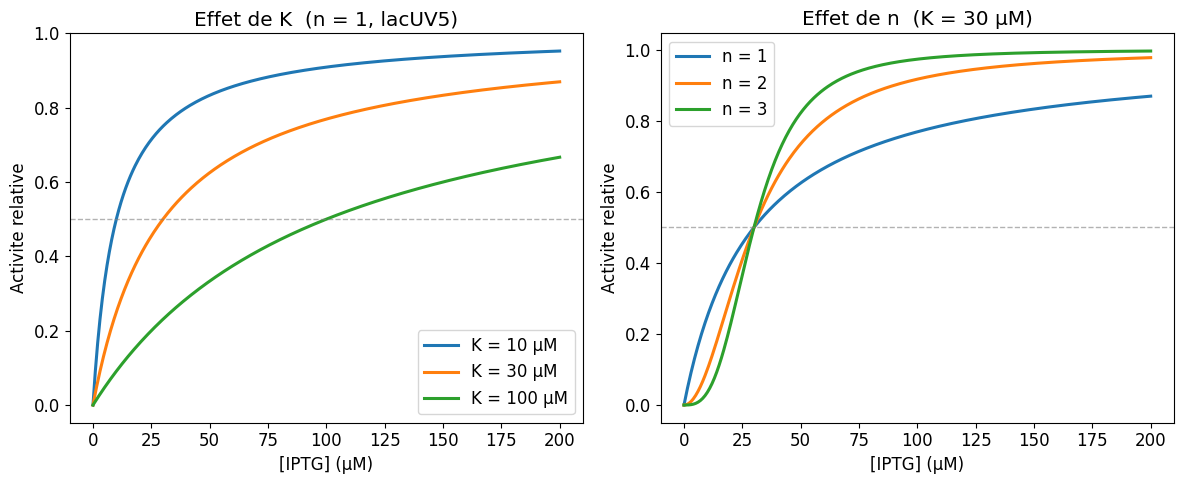

Questions :
  1. K augmente -> la courbe se deplace vers la droite.
     Biologiquement : le represseur se lie moins bien a l'IPTG.
  2. n augmente -> la transition est plus abrupte.
     Biologiquement : plus d'operateurs cooperatifs impliques.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Gauche : effet de K  (n = 1 fixé) ──────────────────────────────────────────
for K_test in [10, 30, 100]:
    f = I_vals / (K_test + I_vals)
    axes[0].plot(I_vals, f, lw=2.2, label=f'K = {K_test} µM')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.6, lw=1)
axes[0].set_xlabel("[IPTG] (µM)")
axes[0].set_ylabel("Activite relative")
axes[0].set_title("Effet de K  (n = 1, lacUV5)")
axes[0].legend()

# ── Droite : effet de n  (K = 30 µM fixé) ──────────────────────────────────────
K_fix = 30
for n_test in [1, 2, 3]:
    f = I_vals**n_test / (K_fix**n_test + I_vals**n_test)
    axes[1].plot(I_vals, f, lw=2.2, label=f'n = {n_test}')
axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.6, lw=1)
axes[1].set_xlabel("[IPTG] (µM)")
axes[1].set_ylabel("Activite relative")
axes[1].set_title("Effet de n  (K = 30 µM)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Questions :")
print("  1. K augmente -> la courbe se deplace vers la droite.")
print("     Biologiquement : le represseur se lie moins bien a l'IPTG.")
print("  2. n augmente -> la transition est plus abrupte.")
print("     Biologiquement : plus d'operateurs cooperatifs impliques.")

---
## Section B3 — Données réelles du plate reader

Vous avez mesuré la fluorescence (GFP) et la densité optique (OD600) de deux souches
dans différentes concentrations d'IPTG, en plaque 96 puits.

**Objectif** :
1. Charger et nettoyer le fichier BioTek Gen5
2. Identifier et corriger l'autofluorescence (signal des flavines à $[\text{IPTG}]=0$)
3. Calculer la fluorescence normalisée par cellule (RFU/OD corrigée)
4. Tracer les courbes dose-réponse pour les deux souches
5. Lire $K_{1/2}$ graphiquement et superposer la courbe théorique de Hill

### Format du fichier BioTek Gen5

Le logiciel Gen5 exporte un fichier `.txt` avec **deux blocs concaténés** :
- Bloc OD : nom de canal contenant `600`  (ex. `OD600_Read:600`)
- Bloc GFP : nom de canal contenant `470` ou `525`  (ex. `GFP_Read:470,525`)

Chaque bloc : nom du canal → ligne vide → en-tête (Time, T°, A1…H12) → données (TSV).
Le temps est au format `H:MM:SS`.

In [16]:
import pandas as pd

def parse_biotek(filepath):
    # Lit un fichier plate reader BioTek Gen5 (deux blocs OD + GFP, format TSV).
    # Format : nom_canal -> ligne vide -> en-tete -> donnees (time H:MM:SS, sep tabulation)
    # Retourne un dict {nom_canal : DataFrame}
    # Chaque DataFrame : colonne 'temps_h' (heures decimales) + colonnes A1...H12.
    with open(filepath, encoding='utf-8', errors='replace') as f:
        lines = f.read().splitlines()

    # Debut de bloc = ligne non vide, sans tabulation, ne commencant pas par un chiffre
    block_starts = []
    for i, line in enumerate(lines):
        s = line.strip()
        if s and chr(9) not in s and not s[0].isdigit():
            block_starts.append(i)

    result = {}
    for b_idx, b_start in enumerate(block_starts):
        canal_name = lines[b_start].strip()
        if b_start + 2 >= len(lines):
            continue
        header = lines[b_start + 2].strip().split(chr(9))
        # header[0]='Time', header[1]='T...', header[2:]= A1, A2, ..., H12

        b_end = (block_starts[b_idx + 1]
                 if b_idx + 1 < len(block_starts) else len(lines))

        rows = []
        for line in lines[b_start + 3 : b_end]:
            parts = line.strip().split(chr(9))
            if len(parts) < 3:
                continue
            t_str = parts[0]
            if not t_str or t_str == '0:00:00':
                continue
            t_parts = t_str.split(':')
            if len(t_parts) != 3:
                continue
            try:
                h, m, s = int(t_parts[0]), int(t_parts[1]), int(t_parts[2])
            except ValueError:
                continue
            temps_h = h + m / 60 + s / 3600
            rows.append([temps_h] + parts[2:])   # ignorer la colonne T (index 1)

        if not rows:
            continue

        puits  = header[2:]
        n_cols = len(rows[0]) - 1
        cols   = ['temps_h'] + puits[:n_cols]
        df = pd.DataFrame(rows, columns=cols)
        for col in df.columns[1:]:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        result[canal_name] = df

    return result


def trouver_canal(data, mot_cle):
    # Retourne le DataFrame dont le nom de canal contient mot_cle.
    # Exemples : '600' pour OD, '470' ou '525' pour GFP  (BioTek : GFP_Read:470,525)
    for nom in data:
        if mot_cle in nom:
            return data[nom]
    available = list(data.keys())
    raise KeyError(f"Aucun canal avec '{mot_cle}'. Disponibles : {available}")


print("Fonctions parse_biotek et trouver_canal definies.")
print()
print("Usage :")
print("  data   = parse_biotek('votre_fichier.txt')")
print("  od_df  = trouver_canal(data, '600')")
print("  gfp_df = trouver_canal(data, '470')   # ou '525'")

Fonctions parse_biotek et trouver_canal definies.

Usage :
  data   = parse_biotek('votre_fichier.txt')
  od_df  = trouver_canal(data, '600')
  gfp_df = trouver_canal(data, '470')   # ou '525'


In [17]:
# ══════════════════════════════════════════════════════════════════════════════════
# Pour charger VOS données, décommentez ces 3 lignes et adaptez le nom de fichier :
# ══════════════════════════════════════════════════════════════════════════════════
# data   = parse_biotek('mon_experience.txt')
# od_df  = trouver_canal(data, '600')
# gfp_df = trouver_canal(data, '470')   # ou '525'  selon votre instrument

# ── Données synthétiques — À REMPLACER par vos données réelles ─────────────────
# Layout fictif aligné sur la plaque réelle :
#   Colonnes 1-6  : IPTG  (6 conc.) x 2 réplicats (rangées A/B pour Plac-GFP, C/D pour lacUV5-GFP)
#   Colonnes 7-12 : TMG   (6 conc.) x 2 réplicats (mêmes rangées)
#   Rangée E : blancs
np.random.seed(0)

n_pts   = 48
temps_h = np.linspace(0, 8, n_pts)
concs   = [0, 1, 3, 10, 30, 100]   # µM

od_data  = {'temps_h': temps_h}
gfp_data = {'temps_h': temps_h}

for row_plac, row_lacuv, inducteur, col_offset in [
        ('A', 'C', 'IPTG', 0),
        ('B', 'D', 'TMG',  6)]:
    for row in [row_plac, row_lacuv]:
        K_hill = 30 if row in ('A', 'B') else 15
        n_hill =  2 if row in ('A', 'B') else  1
        for col_idx, conc in enumerate(concs):
            col  = col_idx + col_offset + 1
            puit = f"{row}{col}"
            od   = 0.08 + 0.15 / (1 + np.exp(-1.2 * (temps_h - 3.5)))
            od  += np.random.normal(0, 0.003, n_pts)
            denom = K_hill**n_hill + conc**n_hill + 1e-9
            hill  = conc**n_hill / denom
            gfp   = od * (200 * hill + 20) + np.random.normal(0, 8, n_pts)
            od_data[puit]  = np.clip(od,  0.01, None)
            gfp_data[puit] = np.clip(gfp, 0,    None)

# Blancs (rangée E)
for col in range(1, 13):
    puit = f"E{col}"
    od_data[puit]  = np.full(n_pts, 0.05) + np.random.normal(0, 0.002, n_pts)
    gfp_data[puit] = np.full(n_pts, 18)   + np.random.normal(0, 4,     n_pts)

od_df  = pd.DataFrame(od_data)
gfp_df = pd.DataFrame(gfp_data)

print("Donnees synthetiques generees — layout aligne sur la plaque reelle.")
print(f"  {len(od_df)} points, {len(od_df.columns)-1} puits")
print(f"  Duree : {od_df['temps_h'].min():.1f} – {od_df['temps_h'].max():.1f} h")
print(od_df[['temps_h', 'A1', 'B7', 'C1', 'D7']].head(3).to_string(index=False))

Donnees chargees.
  48 points de mesure, 36 puits
  Duree : 0.0 - 8.0 h

 temps_h       A1       A4       B1       B4
0.000000 0.087508 0.084286 0.083598 0.084343
0.170213 0.083910 0.086615 0.081506 0.083978
0.340426 0.086246 0.081425 0.080396 0.073959


### Vérification des courbes de croissance

Avant d'analyser la fluorescence, vérifiez que la croissance s'est bien passée :
- Toutes les courbes OD montent (pas de puits stérile ou contaminé)
- Les réplicats se superposent bien
- Les puits **blancs** (milieu seul) restent plats

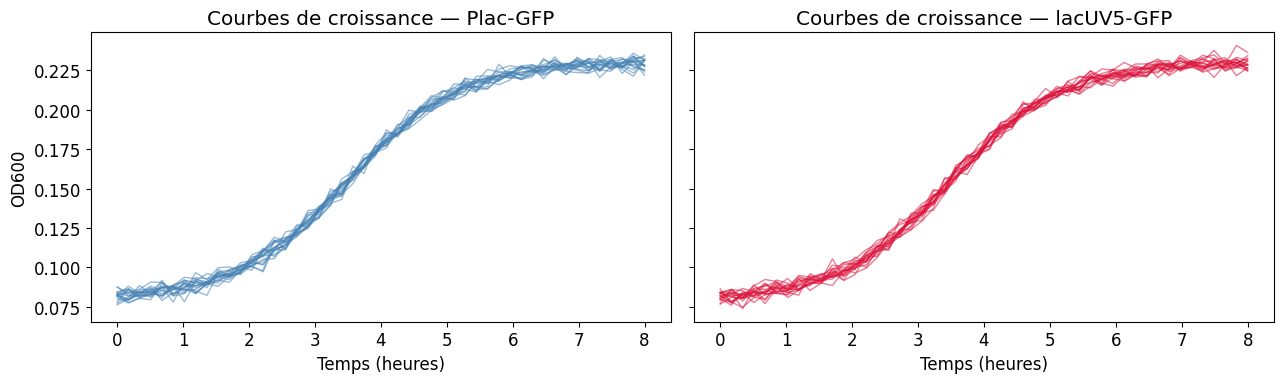

Verifications :
  -> Toutes les courbes montent ?
  -> Les replicats se superposent ?
  -> Les blancs restent plats ?


In [18]:
# ══════════════════════════════════════════════════════════════════════════════════
# ADAPTER : remplacer 'A' et 'B' et les indices par vos rangees reelles
# ══════════════════════════════════════════════════════════════════════════════════
puits_plac  = [f"A{i}" for i in range(1, 13)] + [f"B{i}" for i in range(1, 13)]  # 2 rep x 12 colonnes
puits_lacuv = [f"C{i}" for i in range(1, 13)] + [f"D{i}" for i in range(1, 13)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for puit in puits_plac:
    if puit in od_df.columns:
        axes[0].plot(od_df['temps_h'], od_df[puit], alpha=0.55, lw=1, color='steelblue')
axes[0].set_xlabel("Temps (heures)")
axes[0].set_ylabel("OD600")
axes[0].set_title("Courbes de croissance — Plac-GFP")

for puit in puits_lacuv:
    if puit in od_df.columns:
        axes[1].plot(od_df['temps_h'], od_df[puit], alpha=0.55, lw=1, color='crimson')
axes[1].set_xlabel("Temps (heures)")
axes[1].set_title("Courbes de croissance — lacUV5-GFP")

plt.tight_layout()
plt.show()

print("Verifications :")
print("  -> Toutes les courbes montent ?")
print("  -> Les replicats se superposent ?")
print("  -> Les blancs restent plats ?")

### Autofluorescence : le signal sans inducteur

Même **sans inducteur**, les bactéries émettent de la fluorescence dans le canal GFP
(~470/525 nm). Ce signal de fond est dû aux **flavines** (FAD, FMN, riboflavine),
des cofacteurs métaboliques naturellement fluorescents présents dans toutes les cellules.

L'autofluorescence est **proportionnelle à l'OD** (plus de cellules = plus de signal),
donc elle contribue à RFU/OD comme une constante additive qu'il faut soustraire.

> Les puits à $[\text{IPTG}] = 0$ donnent directement le niveau d'autofluorescence.
> Lire RFU/OD en **phase exponentielle** (OD modéré) où l'état métabolique est stable
> et l'autofluorescence par cellule est constante.

In [ ]:
# ── Visualiser l'autofluorescence ─────────────────────────────────────────────
couleurs_s = {'Plac-GFP': 'crimson', 'lacUV5-GFP': 'steelblue'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Gauche : RFU/OD au cours du temps — sans inducteur vs IPTG max ─────────────
for souche in layout:
    for conc, style, alpha, lw_v, lbl_suf in [
            (0, '-',  0.9, 2.0, ' — [I]=0 (autoflu)'),
            (concentrations_IPTG[-1], '--', 0.5, 1.2,
             f' — [IPTG]={concentrations_IPTG[-1]} µM')]:
        for j, puit in enumerate(layout[souche]['IPTG'][conc]):
            if puit not in od_df.columns:
                continue
            od_safe  = od_df[puit].replace(0, np.nan)
            rfu_od_t = gfp_df[puit] / od_safe
            lbl = souche + lbl_suf if j == 0 else ''
            axes[0].plot(od_df['temps_h'], rfu_od_t, style,
                        color=couleurs_s[souche], alpha=alpha, lw=lw_v, label=lbl)

axes[0].set_xlabel("Temps (heures)")
axes[0].set_ylabel("RFU / OD")
axes[0].set_title("Sans inducteur (—) vs IPTG saturant (- -)")
axes[0].legend(fontsize=8)

# ── Droite : GFP brut vs OD — tous les puits (teinte = [IPTG]) ─────────────────
cmap   = plt.cm.viridis
norm_c = plt.Normalize(0, concentrations_IPTG[-1])
for souche in layout:
    for conc in concentrations_IPTG:
        for puit in layout[souche]['IPTG'][conc]:
            if puit in od_df.columns:
                axes[1].scatter(od_df[puit], gfp_df[puit],
                               color=cmap(norm_c(conc)), alpha=0.4, s=8)

plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_c),
             ax=axes[1], label='[IPTG] (µM)')
axes[1].set_xlabel("OD600")
axes[1].set_ylabel("GFP (RFU brute)")
axes[1].set_title("GFP brut vs OD — tous les puits")

plt.tight_layout()
plt.show()

print("Observations :")
print("  1. À [IPTG]=0 (trait plein) : RFU/OD non nul et stable → autofluorescence.")
print("     Ce signal vient des flavines (FAD, FMN), pas de la GFP.")
print("  2. Graphe de droite : les points [IPTG]=0 forment une droite → autoflu ∝ OD.")
print("  3. Quelle est la valeur approximative d'autofluorescence (RFU/OD) ?")

### Définition du layout de plaque

**Cette section est à adapter à votre expérience.**

Le dictionnaire `layout` relie chaque souche et chaque concentration à ses 3 puits réplicats.
Modifiez les noms de puits selon votre plan de plaque réel.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════════
# ADAPTER A VOTRE EXPERIENCE
# ══════════════════════════════════════════════════════════════════════════════════
concentrations_IPTG = [0, 1, 3, 10, 30, 100]   # µM — colonnes 1-6
concentrations_TMG  = [0, 1, 3, 10, 30, 100]   # µM — colonnes 7-12

# layout[souche][inducteur][concentration] = [puit_rep1, puit_rep2]
layout = {
    'Plac-GFP': {
        'IPTG': {conc: [f"A{i+1}", f"B{i+1}"] for i, conc in enumerate(concentrations_IPTG)},
        'TMG':  {conc: [f"A{i+7}", f"B{i+7}"] for i, conc in enumerate(concentrations_TMG)},
    },
    'lacUV5-GFP': {
        'IPTG': {conc: [f"C{i+1}", f"D{i+1}"] for i, conc in enumerate(concentrations_IPTG)},
        'TMG':  {conc: [f"C{i+7}", f"D{i+7}"] for i, conc in enumerate(concentrations_TMG)},
    },
}

print("Layout defini (2 replicats, IPTG col 1-6, TMG col 7-12) :")
for souche, ind_dict in layout.items():
    for ind, cond_dict in ind_dict.items():
        for conc, puits_liste in cond_dict.items():
            print(f"  {souche:12s} | {ind:4s} | [{conc:3d} µM] | {puits_liste}")

Layout defini :
  Plac-GFP     | [IPTG] =    0 µM | ['A1', 'A2', 'A3']
  Plac-GFP     | [IPTG] =    1 µM | ['A4', 'A5', 'A6']
  Plac-GFP     | [IPTG] =    3 µM | ['A7', 'A8', 'A9']
  Plac-GFP     | [IPTG] =   10 µM | ['A10', 'A11', 'A12']
  Plac-GFP     | [IPTG] =   30 µM | ['A13', 'A14', 'A15']
  Plac-GFP     | [IPTG] =  100 µM | ['A16', 'A17', 'A18']
  lacUV5-GFP   | [IPTG] =    0 µM | ['B1', 'B2', 'B3']
  lacUV5-GFP   | [IPTG] =    1 µM | ['B4', 'B5', 'B6']
  lacUV5-GFP   | [IPTG] =    3 µM | ['B7', 'B8', 'B9']
  lacUV5-GFP   | [IPTG] =   10 µM | ['B10', 'B11', 'B12']
  lacUV5-GFP   | [IPTG] =   30 µM | ['B13', 'B14', 'B15']
  lacUV5-GFP   | [IPTG] =  100 µM | ['B16', 'B17', 'B18']


### Normalisation : RFU / OD (avec correction autofluorescence)

La fluorescence brute (RFU) dépend à la fois du niveau d'expression **par cellule**
et du nombre de cellules (proportionnel à l'OD). Pour isoler l'expression par cellule :

$$\text{RFU/OD}(t) = \frac{\text{GFP}(t)}{\text{OD}(t)}$$

On commence par soustraire l'**autofluorescence** : la valeur RFU/OD mesurée
à $[\text{IPTG}]=0$ (dû aux flavines, pas à la GFP).
Puis on prend cette valeur corrigée à un instant fixé en **phase exponentielle** (4–5 h).

> Modifiez `t_lecture` et observez l'effet sur les courbes dose-réponse.

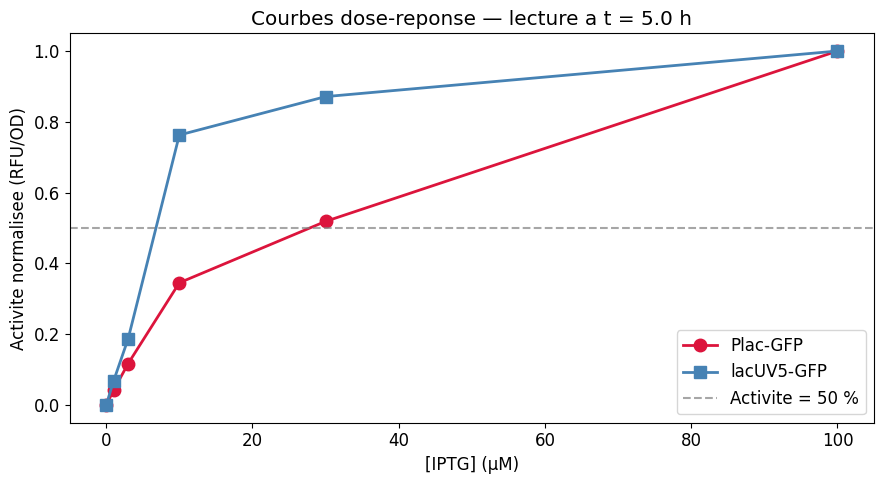

-> Lecture graphique :
   Trouvez la concentration ou chaque courbe croise la ligne 0.5.

   K_half (Plac-GFP)   ≈ ??? µM
   K_half (lacUV5-GFP) ≈ ??? µM


In [20]:
# ── Temps de lecture ────────────────────────────────────────────────────────────
t_lecture = 5.0    # heures — modifier pour explorer l'effet
inducteur_analyse = 'IPTG'  # ou 'TMG' pour analyser les donnees TMG

# ── Fonction : RFU/OD au temps le plus proche de t_lecture ─────────────────────
def rfu_od(od_df, gfp_df, puit, t):
    # Calcule RFU/OD pour un puit au temps le plus proche de t.
    if puit not in od_df.columns or puit not in gfp_df.columns:
        return np.nan
    idx    = (od_df['temps_h'] - t).abs().idxmin()
    od_val = od_df.loc[idx, puit]
    gf_val = gfp_df.loc[idx, puit]
    return np.nan if od_val <= 0 else gf_val / od_val

# ── Autofluorescence : RFU/OD moyen à [I] = 0 ─────────────────────────────────
rfu_autoflu = {}
for souche in layout:
    vals = [rfu_od(od_df, gfp_df, p, t_lecture)
            for p in layout[souche][inducteur_analyse][0] if p in od_df.columns]
    rfu_autoflu[souche] = np.nanmean(vals)
    print(f"Autofluorescence {souche:12s} : {rfu_autoflu[souche]:.1f} RFU/OD")
print()

# ── Calculer RFU/OD par condition, soustraire l'autofluorescence ───────────────
resultats = {}
for souche in layout:
    moyennes = []
    for conc in concentrations_IPTG:
        vals = [rfu_od(od_df, gfp_df, p, t_lecture)
                for p in layout[souche][inducteur_analyse][conc]]
        moyennes.append(np.nanmean(vals))
    arr = np.array(moyennes)
    resultats[souche] = arr - rfu_autoflu[souche]   # correction autofluorescence

# ── Normaliser entre 0 et 1 pour comparaison visuelle ──────────────────────────
def normaliser(arr):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo)

couleurs  = {'Plac-GFP': 'crimson', 'lacUV5-GFP': 'steelblue'}
marqueurs = {'Plac-GFP': 'o',       'lacUV5-GFP': 's'}

plt.figure(figsize=(9, 5))
for souche in layout:
    y = normaliser(resultats[souche])
    plt.plot(concentrations_IPTG, y,
             marqueurs[souche] + '-', color=couleurs[souche], ms=9, lw=2,
             label=souche)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Activite = 50 %')
plt.xlabel(f"[{inducteur_analyse}] (µM)")
plt.ylabel("Activite normalisee (RFU/OD corrigee)")
plt.title(f"Courbes dose-reponse — lecture a t = {t_lecture} h")
plt.legend()
plt.tight_layout()
plt.show()

print("-> Lecture graphique :")
print("   K_half (Plac-GFP)   ≈ ??? µM")
print("   K_half (lacUV5-GFP) ≈ ??? µM")

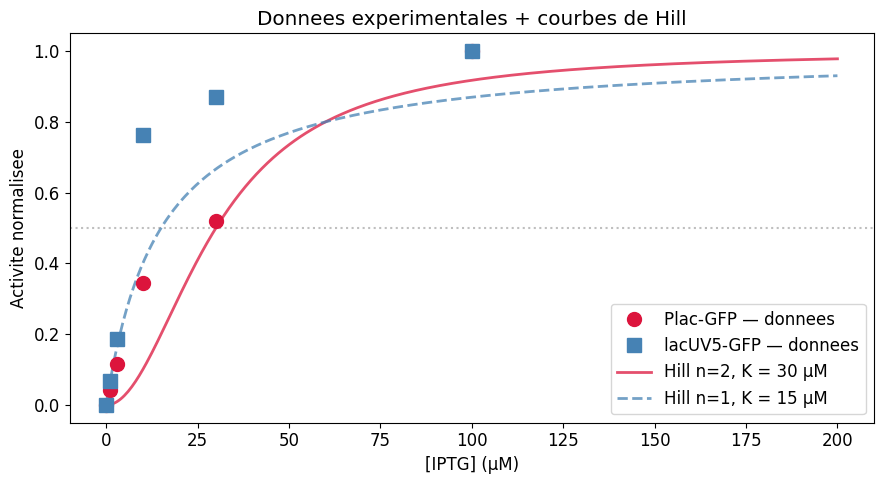

Questions :
  1. La courbe Plac est-elle plus sigmoide que lacUV5 dans vos donnees ?
  2. Les K_half sont-ils differents pour les deux promoteurs ?
  3. Quelle serait la consequence d'un K_half plus eleve pour la cellule ?


In [21]:
# ── Entrez vos K_half lus graphiquement ────────────────────────────────────────
K_plac  = 30    # µM — a ajuster selon votre lecture
K_lacuv = 15    # µM — a ajuster selon votre lecture

# ── Courbes théoriques de Hill ─────────────────────────────────────────────────
I_dense = np.linspace(0, 200, 400)
f_plac_th  = I_dense**2 / (K_plac**2  + I_dense**2)   # Hill n=2
f_lacuv_th = I_dense    / (K_lacuv    + I_dense)       # Hill n=1

# ── Tracé données + théorie ────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))

for souche in layout:
    y = normaliser(resultats[souche])
    plt.plot(concentrations_IPTG, y,
             marqueurs[souche], color=couleurs[souche], ms=10, zorder=4,
             label=f'{souche} — donnees')

plt.plot(I_dense, f_plac_th,  '-',  color='crimson',   lw=2, alpha=0.75,
         label=f'Hill n=2, K = {K_plac} µM')
plt.plot(I_dense, f_lacuv_th, '--', color='steelblue', lw=2, alpha=0.75,
         label=f'Hill n=1, K = {K_lacuv} µM')

plt.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
plt.xlabel("[IPTG] (µM)")
plt.ylabel("Activite normalisee")
plt.title("Donnees experimentales + courbes de Hill")
plt.legend()
plt.tight_layout()
plt.show()

print("Questions :")
print("  1. La courbe Plac est-elle plus sigmoide que lacUV5 dans vos donnees ?")
print("  2. Les K_half sont-ils differents pour les deux promoteurs ?")
print("  3. Quelle serait la consequence d'un K_half plus eleve pour la cellule ?")

---
## Pour aller plus loin

1. **Comparer IPTG et TMG** : refaire §B3 avec les données TMG.
   Les courbes dose-réponse sont-elles différentes de l'IPTG ? Plus bruitées ?

2. **Si vous faites le Notebook C** : l'analyse single-cell que vous allez réaliser
   est proche de l'expérience fondatrice d'Elowitz et al. (2002).
   Dans ce papier, deux gènes rapporteurs identiques dans la même cellule montraient
   des niveaux d'expression différents — preuve directe du bruit *intrinsèque*.

3. **Raffinement du fit** : la lecture graphique de $K_{1/2}$ est approximative.
   Pouvez-vous trouver la valeur qui minimise visuellement l'écart entre points
   et courbe théorique ? C'est le principe du fit numérique.

4. **Prédiction** : que se passerait-il si on mesurait Plac-GFP dans une souche
   $\Delta lacI$ (sans répresseur) ? À quel niveau d'expression attendez-vous la GFP ?